In [1]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import e

In [2]:
class ParserException(Exception):
  pass

class HHparserException(ParserException):
  pass

class HHParserNotParsedException(HHparserException):
  pass

In [38]:
class HHParser:
  def __init__(self, name, russian_query, area=1):
    self.query = name
    self.russian_query = russian_query
    self.url = f"https://hh.ru/vacancies/{self.query}"
    self.area = area
    self.headers = {'User-Agent': 'Mozilla/5.0...'}
    self.full_html = ''

  def parse(self, start_page, end_page):
    all = []
    with requests.Session() as session:
      session.headers.update(self.headers)
      for i in range(start_page, end_page+1):
        r = session.get(self.url, params={
            #'text': self.query, 'area': self.area, 'per_page': 50,
            'page': i}, timeout = 10)
        r.raise_for_status()
        html = r.text
        self.full_html = self.full_html + html
        soup = BeautifulSoup(html)
        jobs = soup.find_all('a', attrs={'data-qa': "serp-item__title"})
        all.extend(jobs)
    return all

  def get_salary_and_name(self, cards: list):
    all, only_with_salaries = [], []
    for j in cards:
      salary = j.parent.parent.find('span', class_=lambda c: c and 'label-1-regular' in c)
      job_type = j.parent.parent.find('span', {'data-qa': 'serp-item__title-text'}).get_text()
      if salary is None:
        new = (job_type, None, None)
        all.append(new)
        continue
      sal = re.sub(r'\s+', ' ', salary.get_text())
      lili = sal.split()
      first, second = None, None
      first_got = False
      for i in range(0, len(lili)):
        if lili[i].isdigit() == True and lili[i+1] == '000' and first_got == False:
          first = int(lili[i] + lili[i+1])
          first_got = True
        if i!=len(lili) and lili[i].isdigit() == True and lili[i+1] == '000' and first_got == True:
          second = int(lili[i] + lili[i+1])
      new = (job_type, first, second)
      all.append(new)
      only_with_salaries.append(new)
    self.jobs = all
    self.jobs_with_sal = only_with_salaries

  def make_pandas(self):
    starts, ends, names = [], [], []
    if not hasattr(self, 'jobs_with_sal'):
      raise HHParserNotParsedException('вы не пропарсили еще')
    for name, start, end in self.jobs_with_sal:
      starts.append(start)
      ends.append(end)
      names.append(name)
    st, en, na = pd.Series(starts), pd.Series(ends), pd.Series(names)
    df = pd.DataFrame({'job': na, 'min': st, 'max': en})
    df['average'] = (df['min']+df['max'])/2
    self.df = df

  def clean_pandas(self, job):
    clean_df = self.df[self.df['job'].str.contains(job, case=False)]
    clean_clean_df = clean_df.dropna()
    self.df = clean_clean_df

  def make_graphics(self):
    if not hasattr(self, 'df'):
        raise HHParserNotParsedException('айайай датафрейм не создан, надо работать через make_everything')

    palette = ['HotPink', 'Indigo', '#7B68EE', '#FFD700']
    sns.set_style('white')

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Зарплаты: {self.russian_query}', fontsize=15, fontweight='bold')

    # гистограмма со средним и медианой
    axes[0].hist(self.df['average'].dropna(), bins=10,
                 color=palette[0], edgecolor='white', alpha=0.85)
    axes[0].set_title('Распределение средних зарплат')
    axes[0].set_xlabel('Зарплата (руб.)')
    axes[0].set_ylabel('Кол-во вакансий')
    axes[0].axvline(self.mean, color=palette[1], linestyle='-',
                    linewidth=2, label=f'среднее: {self.mean:,} руб.')
    axes[0].axvline(self.median, color=palette[3], linestyle='--',
                    linewidth=2, label=f'медиана: {self.median:,} руб.')
    axes[0].legend()

    # boxplot min/max
    data_box = [self.df['min'].dropna(), self.df['max'].dropna()]
    bp = axes[1].boxplot(data_box, tick_labels=['Минимальная', 'Максимальная'],
                         patch_artist=True)
    bp['boxes'][0].set_facecolor(palette[0])
    bp['boxes'][1].set_facecolor(palette[2])
    for median_line in bp['medians']:
        median_line.set_color(palette[1])
        median_line.set_linewidth(2)
    axes[1].set_title('Разброс зарплат (min / max)')
    axes[1].set_ylabel('Зарплата (руб.)')

    # violinplot
    df_melt = self.df[['min', 'max']].dropna().melt(
        var_name='тип', value_name='зарплата')
    df_melt['тип'] = df_melt['тип'].map({'min': 'Минимальная', 'max': 'Максимальная'})
    sns.violinplot(data=df_melt, x='тип', y='зарплата', hue='тип',
               palette={'Минимальная': palette[0], 'Максимальная': palette[2]},
               inner='quartile', legend=False, ax=axes[2])
    axes[2].axhline(self.mean, color=palette[1], linestyle='-',
                    linewidth=2, label=f'среднее: {self.mean:,}')
    axes[2].axhline(self.median, color=palette[3], linestyle=':',
                    linewidth=2, label=f'медиана: {self.median:,}')
    axes[2].set_title('Форма распределения зарплат')
    axes[2].set_xlabel('')
    axes[2].set_ylabel('Зарплата (руб.)')
    axes[2].legend()

    plt.tight_layout();

  def make_everything(self, start_page: int = 0, end_page: int = 5):
    li = self.parse(start_page, end_page)
    self.get_salary_and_name(li)
    self.make_pandas()
    self.clean_pandas(self.russian_query)
    self.mean = round(self.df['average'].mean(), 1).item()
    self.median = round(self.df['average'].median(), 1)
    self.make_graphics()

Среднее: 109510.9, медиана: 110000.0


,job,min,max,average
1,Помощник грумера,40000,50000,45000.0
3,"Грумер/ученик, Москва",40000,40000,40000.0
4,Грумер,90000,150000,120000.0
8,Грумер,130000,130000,130000.0
9,Грумер,100000,100000,100000.0


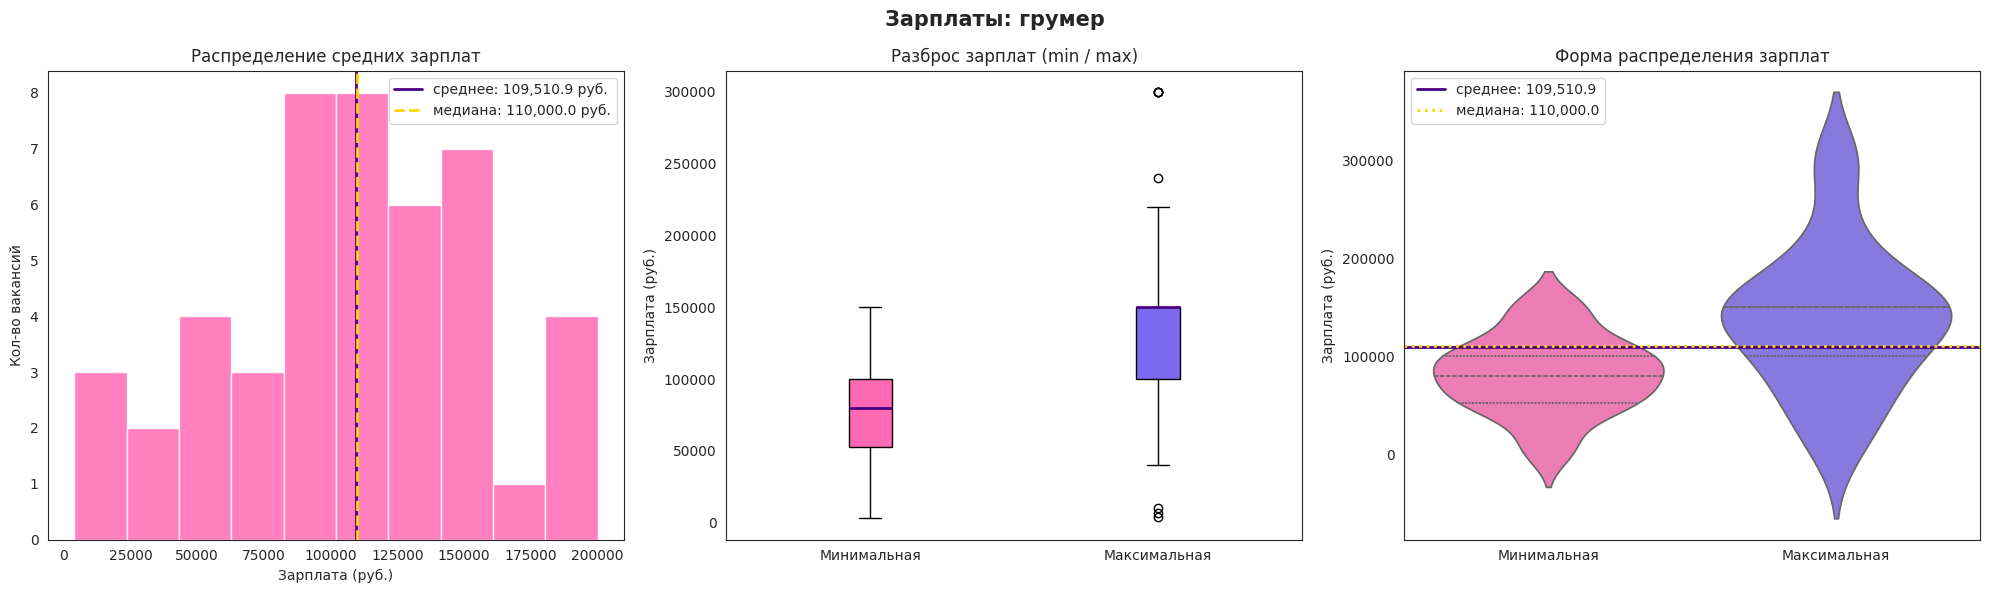

In [35]:
grumers = HHParser('grumer', 'грумер')
grumers.make_everything(0, 2)
print(f'Среднее: {grumers.mean}, медиана: {grumers.median}')
grumers.df.head()

Среднее: 163612.5, медиана: 150000.0


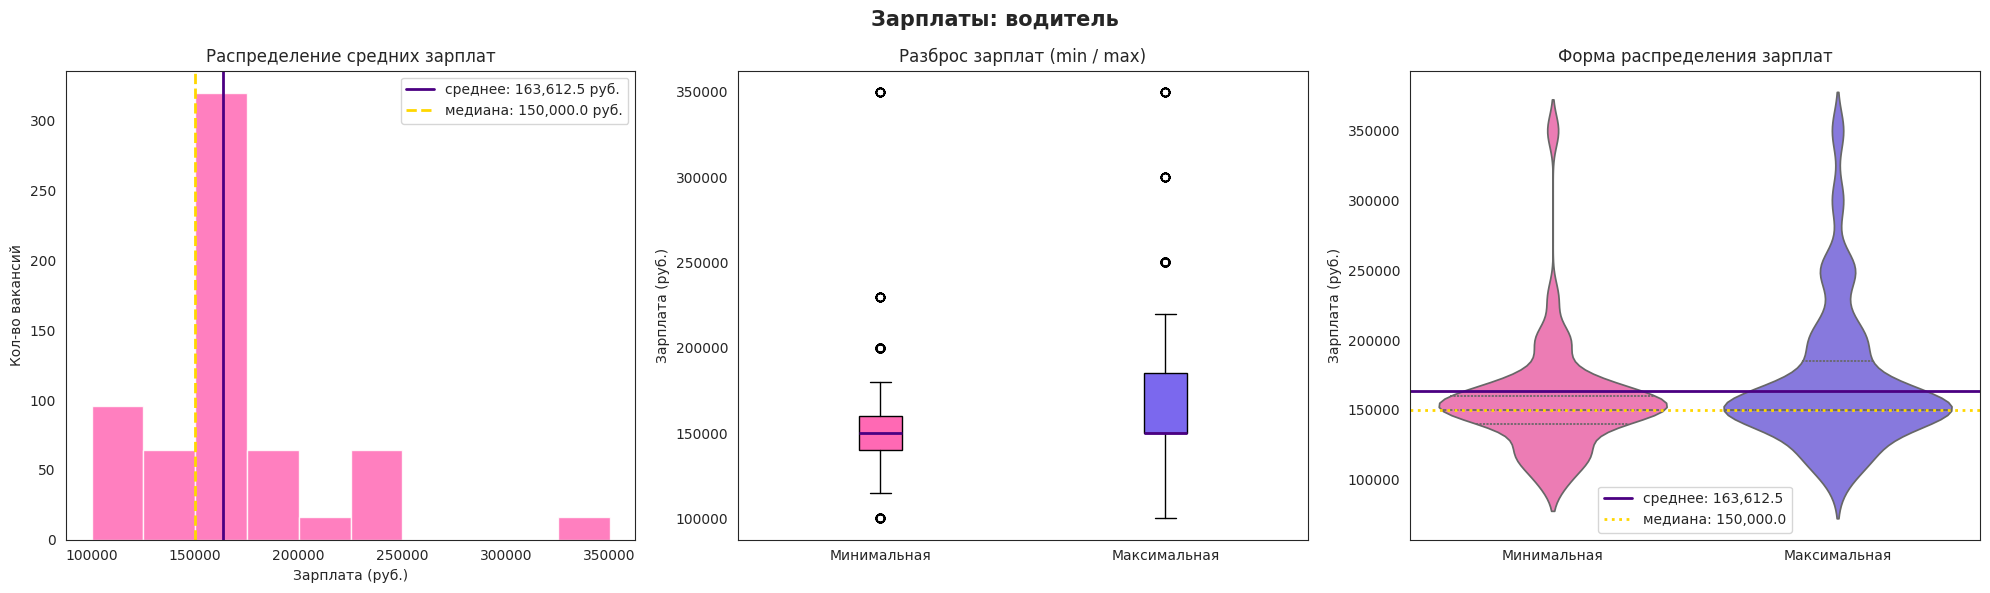

In [41]:
drivers = HHParser('driver', 'водитель')
drivers.make_everything(0, 15)
print(f'Среднее: {drivers.mean}, медиана: {drivers.median}')

In [42]:
len(drivers.df)

640

In [43]:
drivers.df.head()

,job,min,max,average
0,Водитель в семью (персональный водитель),160000.0,160000.0,160000.0
1,Личный водитель,350000.0,350000.0,350000.0
2,Семейный водитель - помощник,180000.0,200000.0,190000.0
3,Семейный водитель,170000.0,170000.0,170000.0
4,Семейный водитель,150000.0,150000.0,150000.0
